## Training the Model Based on the Cleaned Dataset using Linear Regression

In [58]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df = pd.read_csv("cleaned_housing_dataset.csv")
df.head ()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,3.5296,29.0,6.238137,0.678988,7.063904,1.134572,37.86,-122.22,1.522790
1,7.2574,52.0,8.288136,0.729212,6.208590,1.339664,37.85,-122.24,1.508733
2,5.6431,52.0,5.817352,0.729025,7.063904,1.266369,37.85,-122.25,1.484555
3,3.8462,52.0,6.281853,0.732888,6.338594,1.157342,37.85,-122.25,1.486592
4,4.0368,52.0,4.761658,0.743663,6.025866,1.144190,37.85,-122.25,1.307522


### Splitting and Scaling

In [59]:
X =  df.drop(columns=['target','AveBedrms'])
y = df['target']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=23)
X_train

,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude,Longitude
5287,4.5491,29.0,5.984848,6.489205,1.462834,34.12,-118.01
11329,3.0943,10.0,5.519708,7.623153,1.382272,34.53,-117.33
12945,4.5469,21.0,4.624576,7.742836,1.082667,34.25,-118.50
3981,2.0259,42.0,4.811989,7.019297,1.397135,34.04,-118.32
13641,1.6563,16.0,5.125000,7.063904,1.714743,35.34,-120.69
...,...,...,...,...,...,...,...
6175,2.0625,36.0,5.080357,6.778785,1.593236,33.91,-118.18
9704,4.8400,29.0,6.101190,7.050989,1.488749,33.99,-117.49
11190,3.2604,9.0,5.018106,7.486053,1.247576,34.06,-117.24
9256,4.3550,19.0,5.009890,7.063904,1.144783,33.66,-118.01


In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



### Checking the effect of standardization on the data

<Axes: >

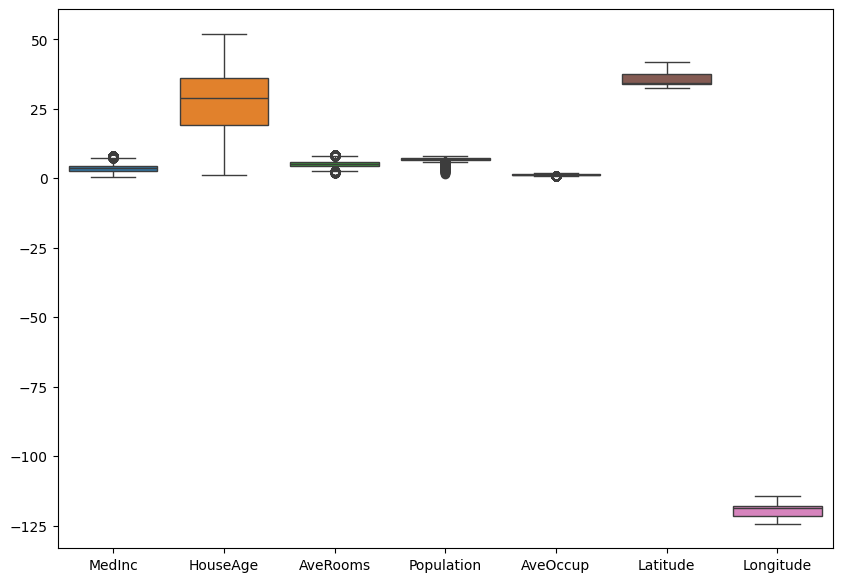

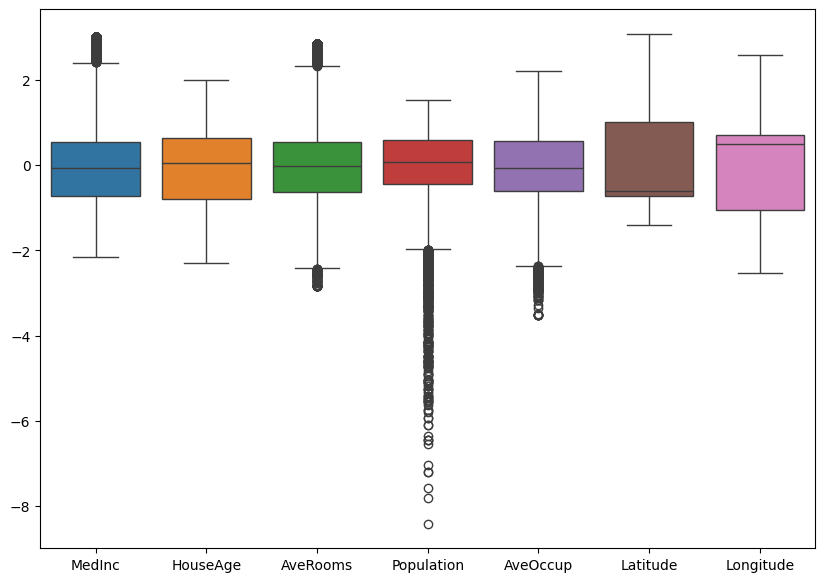

In [61]:
plt.figure(0,figsize=(10,7))
sns.boxplot(X_train)
plt.figure(1,figsize=(10,7))
sns.boxplot(pd.DataFrame(X_train_scaled,columns= X_train.columns))

## Training the Model

In [62]:
model = LinearRegression()
model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
print("Coefficients: ",model.coef_)
print("Intercept: ",model.intercept_)

Coefficients:  [ 0.21903603  0.03996229 -0.03276725  0.0183732  -0.07991357 -0.11064677
 -0.08329647]
Intercept:  1.0137992495203163


In [64]:
y_pred = model.predict(X_test_scaled)

### Evaluation

In [65]:
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test,y_pred)
r2_linear = r2_score(y_test,y_pred)
print("Mean Squared Error: ",mse)
print("R2: ",r2_linear)

Mean Squared Error:  0.0501115705967479
R2:  0.5355116906373618


### Ridge Cross Validation

Mean Squared Error:  0.05011328049262197
R2:  0.5354958414705073


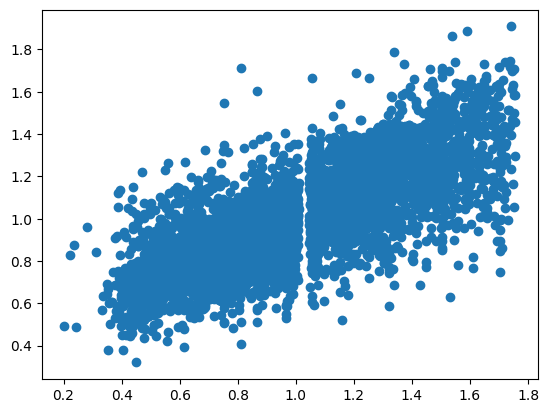

In [66]:
from sklearn.linear_model import RidgeCV
model = RidgeCV(cv=5)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
plt.scatter(y_test,y_pred) # We expect to see a linear relation
mse = mean_squared_error(y_test,y_pred)
r2_ridge = r2_score(y_test,y_pred)
print("Mean Squared Error: ",mse)
print("R2: ",r2_ridge)

### Lasso Cross Validation

Mean Squared Error:  0.050122111144777236
R2:  0.5354139894223411
Alpha selected:  0.00020527900425339586
coefficients:  [ 0.21874869  0.03979177 -0.03251477  0.01814532 -0.07967586 -0.1097839
 -0.082417  ]


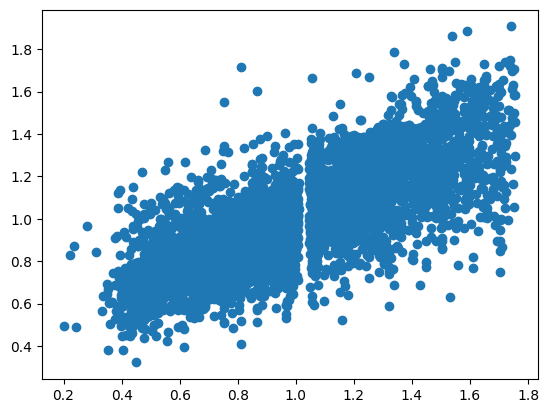

In [79]:
from sklearn.linear_model import LassoCV
model = LassoCV(cv=5)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2_lasso = r2_score(y_test,y_pred)
print("Mean Squared Error: ",mse)
print("R2: ",r2_lasso)
print("Alpha selected: ",model.alpha_)
print("coefficients: ",model.coef_)

### ElasticNet Cross Validation

Mean Squared Error:  0.050122339552370325
R2:  0.5354118722933927


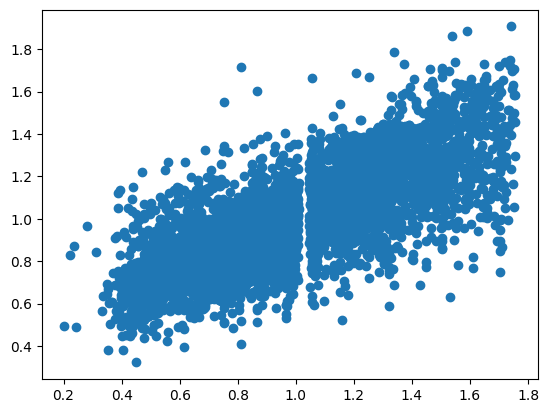

In [71]:
from sklearn.linear_model import ElasticNetCV
model = ElasticNetCV(l1_ratio=0.7,cv=5)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2_elasticnet = r2_score(y_test,y_pred)
print("Mean Squared Error: ",mse)
print("R2: ",r2_elasticnet)

In [72]:
results = {
    "Linear": r2_linear,
    "Ridge": r2_ridge,
    "Lasso": r2_lasso,
    "ElasticNet": r2_elasticnet
}
print(results)

{'Linear': 0.5355116906373618, 'Ridge': 0.5354958414705073, 'Lasso': 0.5354139894223411, 'ElasticNet': 0.5354118722933927}


## All models performed similarly, indicating that regularization does not significantly improve performance. This suggests that the limitation lies in the linear assumption of the model rather than overfitting.